#analysis - Q: Is strain C better at fear conditioning than strain D?

In [ ]:
#Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [ ]:
#Load the csv dataset

infile = "/Users/petsa/Desktop/master/neuro105/data/mouse_cognition.csv"
mice = pd.read_csv(infile)

mice.head(10)

,mouse_id,strain,maze_test,object_recognition,fear_conditioning,social_memory,BDNF,CREB1,DRD2,GRIN1,diet,light_hours,exercise_wheel,age_weeks,weight_g
0,M001,A,78,72,65,70,8.2,6.5,5.8,7.1,standard,12,yes,12,28.5
1,M002,A,82,75,68,73,8.5,6.8,5.6,7.4,standard,12,yes,14,29.2
2,M003,A,75,70,62,68,7.9,6.3,5.9,6.9,standard,12,no,11,27.8
3,M004,A,80,74,66,71,8.3,6.6,5.7,7.2,enriched,12,yes,13,28.1
4,M005,A,77,71,64,69,8.1,6.4,5.8,7.0,standard,12,no,12,28.9
5,M006,A,83,76,69,74,8.6,6.9,5.5,7.5,enriched,12,yes,15,29.5
6,M007,A,76,69,63,67,7.8,6.2,6.0,6.8,high_fat,12,no,10,30.2
7,M008,A,79,73,65,70,8.2,6.5,5.7,7.1,standard,12,yes,13,28.4
8,M009,A,81,74,67,72,8.4,6.7,5.6,7.3,enriched,12,yes,14,28.8
9,M010,A,74,68,61,66,7.7,6.1,6.1,6.7,high_fat,12,no,11,31.1


In [24]:
#Check for missing values

mice.isna().sum()

mouse_id              0
strain                0
maze_test             0
object_recognition    0
fear_conditioning     0
social_memory         0
BDNF                  0
CREB1                 0
DRD2                  0
GRIN1                 0
diet                  0
light_hours           0
exercise_wheel        0
age_weeks             0
weight_g              0
dtype: int64

In [ ]:
#Select strains C and D and their fear_conditioning scores

group_c=mice[mice['strain'] == 'C']['fear_conditioning']
group_d=mice[mice['strain'] == 'D']['fear_conditioning']
print(group_c,group_d)


30    82
31    85
32    79
33    83
34    81
35    86
36    78
37    84
38    87
39    77
40    82
41    84
42    80
43    88
44    83
Name: fear_conditioning, dtype: int64 45    70
46    73
47    67
48    71
49    69
50    74
51    66
52    72
53    75
54    65
55    70
56    72
57    68
58    76
59    71
Name: fear_conditioning, dtype: int64


In [ ]:
#Check the sample size to decide whether to use the t-test or the mann-whitney test

len(group_c+group_d)


30

In [32]:
#Get the mean scores of the two strains

mean_c=group_c.mean()
mean_d=group_d.mean()
difference=mean_c-mean_d
print("Mean score for strain C:", mean_c, "Mean score for strain D:", mean_d)
print("The score difference between the two strains is:", difference)


Mean score for strain C: 82.6 Mean score for strain D: 70.6
The score difference between the two strains is: 12.0


In [ ]:
#Statistical test 

#t-test because of the sample size (n=30)

t_stat, p_value = stats.ttest_ind(group_c,group_d) 
print("t-statistic:", round(t_stat, 2))
print("p-value:", round(p_value, 13))



t-statistic: 10.19
p-value: 6.34e-11


In [ ]:
#Visualization
#The data that will be used for visualization need to be in Dataframe format, which is achieved by the double brackets.

mice_c=mice[mice['strain'] == 'C'][['strain','fear_conditioning']]
mice_d=mice[mice['strain'] == 'D'][['strain','fear_conditioning']]

#Combine the two new Dataframes into one 
mice_cd=pd.concat([mice_c,mice_d])
mice_cd


,strain,fear_conditioning
30,C,82
31,C,85
32,C,79
33,C,83
34,C,81
35,C,86
36,C,78
37,C,84
38,C,87
39,C,77


P-value is: 6.34e-11


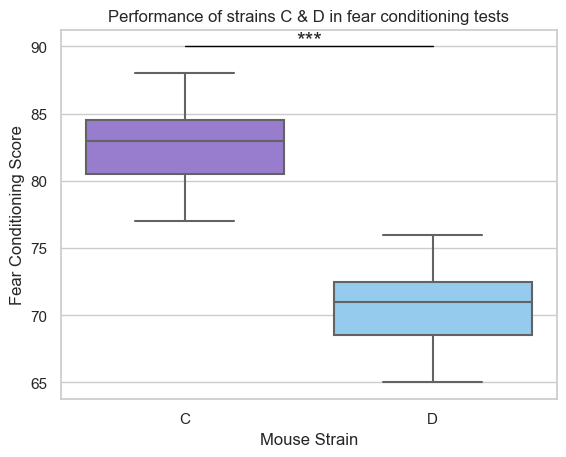

In [ ]:
# Visualization

colors = {'C' : 'mediumpurple','D' : 'lightskyblue'}

sns.boxplot(data=mice_cd, x='strain', y='fear_conditioning', palette=colors)

#Add the statistic difference (***) to the plot
x1, x2 = 0, 1
y = mice_cd['fear_conditioning'].max() + 2 
plt.plot([x1, x1, x2, x2], [y, y, y, y], lw=1, color='black')
plt.text((x1+x2)*.5, y, "***", fontsize=16, ha='center')

plt.title('Performance of strains C & D in fear conditioning tests')
plt.xlabel('Mouse Strain')
plt.ylabel('Fear Conditioning Score')
print("P-value is:", round(p_value, 13))


Interpretation 

Ho: fear conditioning score of strain C = fear conditioning score of strain D 

H1: fear conditioning score of strain C > fear conditioning score of strain D  

p-value < 0.001 --> Ho is rejected

The results suggest that strain C performs better at fear conditioning tests --> could indicate better capacity for associative learning
